<a href="https://colab.research.google.com/github/E-tech-coder/DataScienceCapstoneProject/blob/main/FeatureEngineering%2BRandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/E-tech-coder/DataScienceCapstoneProject.git

Cloning into 'DataScienceCapstoneProject'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 136 (delta 42), reused 20 (delta 20), pack-reused 88 (from 1)
Receiving objects: 100% (136/136), 1.37 MiB | 13.93 MiB/s, done.
Resolving deltas: 100% (75/75), done.


In [ ]:
%cd DataScienceCapstoneProject
!git checkout Michi

/content/DataScienceCapstoneProject/DataScienceCapstoneProject/DataScienceCapstoneProject/DataScienceCapstoneProject/DataScienceCapstoneProject/DataScienceCapstoneProject/DataScienceCapstoneProject/DataScienceCapstoneProject
Branch 'Michi' set up to track remote branch 'Michi' from 'origin'.
Switched to a new branch 'Michi'


In [ ]:
ls

Data_Exploration.ipynb           linkedin-cvs-not-annotated-to-be-predicted
data_exploration_v2.ipynb        linkedin_experience_annotated.csv
department-v2.csv                rulebasedmodel_michi_done.ipynb
df_profiles_cleansed             RuleBasedModel-Michi.ipynb
linkedin-cvs-annotated.json      seniority-v2.csv
linkedin-cvs-not-annotated.json


Goals and approach in advance: Feature engineering + random forest

* Only the characteristics of the current job are predicted, meaning exactly one line per profile. Historical jobs are only used as a feature source. All features are therefore aggregated at the profile level
* There are two separate classification problems, so the models are also treated separately: one for seniority and one for domain



In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("df_profiles_cleansed")
df.sample(10)

,organization,position,startDate,endDate,status,department,seniority,person_id,job_count,job_duration_years
1350,Sto AG,Sales Controller International,2002-10,2004-12,INACTIVE,Sales,Professional,308,8,2.169863
1366,Airbus Defense and Space,Ariane 5 Attitute Control System (SCA) develop...,2004-06,2006-10,INACTIVE,Information Technology,Lead,314,5,2.334247
788,Ground2air Assistance,Station Manager at Ground2Air in Palma de Mall...,2021-05,2025-12,ACTIVE,Other,Lead,183,7,4.589041
2592,Pirelli,Junior Key Account Manager,1995-10,1998-06,INACTIVE,Sales,Junior,602,9,2.668493
1840,Automotive Lighting,Gruppenleiter Entwicklung,2016-01,2020-01,INACTIVE,Information Technology,Lead,416,5,4.002740
1751,HOCHTIEF,Kfm. Leiter / Prokurist der EDL Boysen GmbH (T...,2008-08,2009-09,INACTIVE,Other,Lead,394,10,1.084932
1005,MAINCOR Rohrsysteme GmbH & Co. KG,IT-Leiter,2014-01,2014-12,INACTIVE,Information Technology,Lead,229,6,0.915068
1585,Freiberuflich,IT Consultant,2002-01,2007-01,INACTIVE,Consulting,Professional,360,8,5.002740
1320,FITEC Energy,Développeur,2005-09,2006-02,INACTIVE,Information Technology,Professional,303,7,0.419178
1087,Construction Simco,Directeur des opérations,2015-09,2020-03,INACTIVE,Other,Director,247,8,4.501370


In [ ]:
#how many active jobs are there per person
df_active = df[df["status"] == "ACTIVE"].copy()
df_active["person_id"].value_counts().head()

,count
person_id,
577,10
80,8
212,7
199,5
0,5


In [ ]:
(df[df["status"] == "ACTIVE"]["seniority"].value_counts())

,count
seniority,
Professional,272
Management,210
Lead,138
Senior,48
Director,36
Junior,14


In [ ]:
df["seniority"].value_counts(dropna=False)

,count
seniority,
Professional,1211
Lead,455
Management,408
Junior,230
Senior,170
Director,141


In [ ]:
df["department"].value_counts(dropna=False)

,count
department,
Other,1235
Information Technology,309
Sales,219
Consulting,195
Project Management,173
Marketing,133
Administrative,84
Business Development,78
Purchasing,72


In [ ]:
#Separate raw data
ID_COLS = ["person_id"]

TARGET_COLS = [
    "seniority",
    "department"
]

JOB_COLS = [
    "organization",
    "position",
    "startDate",
    "endDate",
    "status",
    "job_count",
    "job_duration_years"
]

In [ ]:
#split nach personen
profiles = df["person_id"].unique()

In [ ]:
# Stratify nach höchster Seniority pro Person
SENIORITY_RANK = {
    "Junior": 1,
    "Professional": 2,
    "Senior": 3,
    "Lead": 4,
    "Management": 5,
    "Director": 6
}

sen_rank_per_person = (
    df.assign(seniority_rank=df["seniority"].map(SENIORITY_RANK))
      .groupby("person_id")["seniority_rank"]
      .max()
)

In [ ]:
# Rang zurück in Label mappen für stratify
rank_to_label = {v: k for k, v in SENIORITY_RANK.items()}
seniority_label_per_person = sen_rank_per_person.map(rank_to_label)

In [ ]:
#train test split (20/20) für person_id
from sklearn.model_selection import train_test_split

train_profiles, test_profiles = train_test_split(
    profiles,
    test_size=0.2,
    random_state= 0,
    stratify=seniority_label_per_person.loc[profiles]
)

df_train = df[df["person_id"].isin(train_profiles)].copy()
df_test  = df[df["person_id"].isin(test_profiles)].copy()

print("Train persons:", df_train["person_id"].nunique(), "rows:", len(df_train))
print("Test persons:",  df_test["person_id"].nunique(),  "rows:", len(df_test))

Train persons: 485 rows: 2055
Test persons: 122 rows: 560


In [ ]:
#selection for an active job per person regarding start date
def select_unique_active_job(df_in: pd.DataFrame) -> pd.DataFrame:
    df_active = df_in[df_in["status"] == "ACTIVE"].copy()
    df_active["startDate_dt"] = pd.to_datetime(df_active["startDate"], format="%Y-%m", errors="coerce")

    df_active_unique = (
        df_active
        .sort_values(
            by=["person_id", "startDate_dt", "job_duration_years"],
            ascending=[True, False, False]
        )
        .groupby("person_id", as_index=False)
        .first()
        .drop(columns=["startDate_dt"])
    )
    return df_active_unique

train_active_unique = select_unique_active_job(df_train)
test_active_unique  = select_unique_active_job(df_test)

print("Train unique active rows:", len(train_active_unique), "unique persons:", train_active_unique["person_id"].nunique())
print("Test unique active rows:",  len(test_active_unique),  "unique persons:", test_active_unique["person_id"].nunique())

Train unique active rows: 460 unique persons: 460
Test unique active rows: 113 unique persons: 113


Feature Engineering

In [ ]:
#text normalization
def safe_lower(x):
    return x.lower() if isinstance(x, str) else ""

In [ ]:
#adding title statistical features
def add_title_stats(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    titles = df["position"].apply(safe_lower)

    df["title_length"] = titles.str.len()
    df["title_word_count"] = titles.str.split().apply(len)

    return df

In [ ]:
#adding keyword count features
SENIORITY_KEYWORDS = {
    "management": ["ceo","cfo","cto","cmo","chief","vice","president","owner","gesellschafter","founder","cofounder","co-founder","prokurist","prokuristin","unternehmensinhaber","gesch"],
    "director": ["director","global","international","dach"],
    "lead": ["lead","leitung","leiter","head"],
    "senior": ["senior", "sr"],
    "junior": ["intern","junior","trainee","student","werkstudent","referent","assistent","auszubild"],
    "professional": ["analyst","sachbearbeiter"]
}

DEPARTMENT_KEYWORDS = {
    "administrative": ["assistentin","assistenz","assistent","office","assistant","sekret"],
    "business_development": ["business","development","bd"],
    "consulting": ["consultant","berater","sap","dynamics","erp"],
    "customer_support": ["support","customer","supporter"],
    "information_technology": ["software","developer","engineer","architect","devops","cloud","data scientist","data engineer","network","systems administrator","administrator","it"],
    "human_resources": ["human","resources","ressource"],
    "marketing": ["marketing","communication","communications","kommunikation","messe","event"],
    "project_management": ["project","projektleiter","projektmanager","projektmanagement","projekt","projektleitung","projects"],
    "purchasing": ["einkauf","purchas","eink"],
    "sales": ["sales","vertrieb","vertriebsleiter","salesforce"]
}

In [ ]:
def add_keyword_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    titles = df["position"].apply(safe_lower)

    # Seniority keyword counts
    for sen_group, keywords in SENIORITY_KEYWORDS.items():
        df[f"{sen_group}_keyword_count"] = titles.apply(
            lambda x: sum(k in x for k in keywords)
        )

    # Department keyword counts
    for dept, keywords in DEPARTMENT_KEYWORDS.items():
        df[f"{dept}_keyword_count"] = titles.apply(
            lambda x: sum(k in x for k in keywords)
        )

    return df

In [ ]:
train_fe = train_active_unique.copy()
test_fe  = test_active_unique.copy()

train_fe = add_title_stats(train_fe)
train_fe = add_keyword_features(train_fe)

test_fe = add_title_stats(test_fe)
test_fe = add_keyword_features(test_fe)

In [ ]:
#final feature list
FEATURE_COLS = [
    # Karriere
    "job_count",
    "job_duration_years",

    # Titel-Statistik
    "title_length",
    "title_word_count",

    # Keywords
    "management_keyword_count",
    "director_keyword_count",
    "lead_keyword_count",
    "senior_keyword_count",
    "junior_keyword_count",
    "professional_keyword_count",
    "administrative_keyword_count",
    "business_development_keyword_count",
    "consulting_keyword_count",
    "customer_support_keyword_count",
    "information_technology_keyword_count",
    "human_resources_keyword_count",
    "marketing_keyword_count",
    "project_management_keyword_count",
    "purchasing_keyword_count",
    "sales_keyword_count"
]

In [ ]:
#check
train_fe[FEATURE_COLS].isna().sum()

,0
job_count,0
job_duration_years,0
title_length,0
title_word_count,0
management_keyword_count,0
director_keyword_count,0
lead_keyword_count,0
senior_keyword_count,0
junior_keyword_count,0
professional_keyword_count,0


Setting up x and y -> same x for seniority and for department

In [ ]:
X_train = train_fe[FEATURE_COLS]
X_test  = test_fe[FEATURE_COLS]

#seniority
y_train_seniority = train_fe["seniority"]
y_test_seniority  = test_fe["seniority"]

In [ ]:
#department
y_train_department = train_fe["department"]
y_test_department  = test_fe["department"]

In [ ]:
print(X_train.shape, y_train_seniority.shape)
print(X_test.shape, y_test_seniority.shape)

(460, 20) (460,)
(113, 20) (113,)


In [ ]:
X_train.head()


,job_count,job_duration_years,title_length,title_word_count,management_keyword_count,director_keyword_count,lead_keyword_count,senior_keyword_count,junior_keyword_count,professional_keyword_count,administrative_keyword_count,business_development_keyword_count,consulting_keyword_count,customer_support_keyword_count,information_technology_keyword_count,human_resources_keyword_count,marketing_keyword_count,project_management_keyword_count,purchasing_keyword_count,sales_keyword_count
0,3,0.915068,23,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,7,1.249315,30,4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,8,6.339726,24,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2,18.600000,21,2,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
4,1,18.928767,14,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Random Forest Classifier

Feature Importances for Seniority Model:
                                 Feature  Importance
4               management_keyword_count    0.193276
2                           title_length    0.152738
6                     lead_keyword_count    0.142019
1                     job_duration_years    0.128343
0                              job_count    0.088969
3                       title_word_count    0.073460
7                   senior_keyword_count    0.062860
5                 director_keyword_count    0.046093
14  information_technology_keyword_count    0.031576
10          administrative_keyword_count    0.015112
17      project_management_keyword_count    0.010854
19                   sales_keyword_count    0.009449
8                   junior_keyword_count    0.008720
12              consulting_keyword_count    0.008051
11    business_development_keyword_count    0.007029
16               marketing_keyword_count    0.006656
9             professional_keyword_count    0.005101
18   

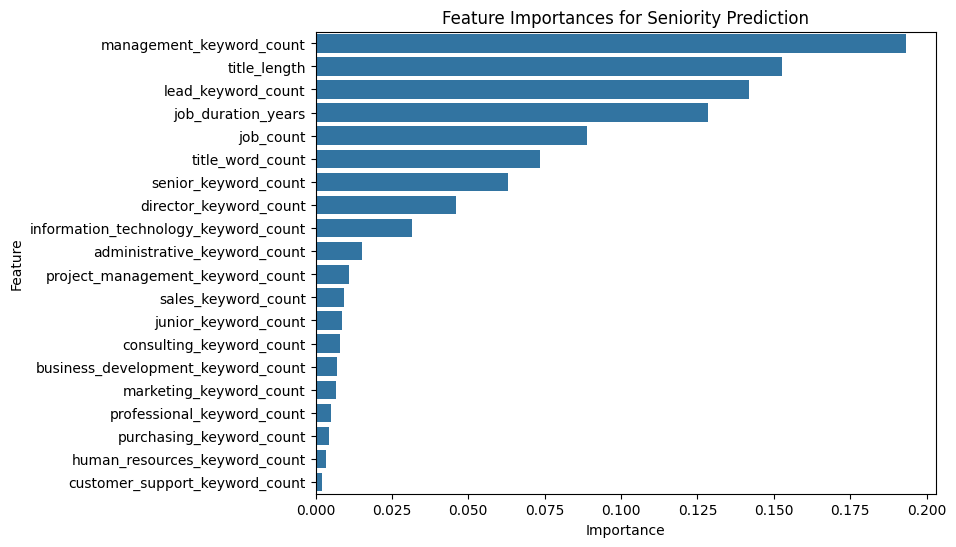

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# get feature importances for seniority model
importance_seniority = rf_seniority.feature_importances_
feature_names = X_train.columns

df_importance_seniority = pd.DataFrame({'Feature': feature_names, 'Importance': importance_seniority})
df_importance_seniority = df_importance_seniority.sort_values(by='Importance', ascending=False)

print("Feature Importances for Seniority Model:")
print(df_importance_seniority)

#visualize feature importances
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance_seniority)
plt.title('Feature Importances for Seniority Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#initialize and train the Random Forest model for seniority
rf_seniority = RandomForestClassifier(random_state=42)
rf_seniority.fit(X_train, y_train_seniority)

#initialize and train the Random Forest model for department
rf_department = RandomForestClassifier(random_state=42)
rf_department.fit(X_train, y_train_department)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

#predict on the test set for seniority
y_pred_seniority = rf_seniority.predict(X_test)

#evaluate seniority model
print("Seniority Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_seniority, y_pred_seniority):.4f}")
print(classification_report(y_test_seniority, y_pred_seniority))

#predict on the test set for department
y_pred_department = rf_department.predict(X_test)

#evaluate department model
print("\nDepartment Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_department, y_pred_department):.4f}")
print(classification_report(y_test_department, y_pred_department))

Seniority Model Evaluation:
Accuracy: 0.7699
              precision    recall  f1-score   support

    Director       0.33      1.00      0.50         1
      Junior       0.00      0.00      0.00         3
        Lead       0.89      0.71      0.79        24
  Management       0.83      0.63      0.72        30
Professional       0.71      0.91      0.80        45
      Senior       0.90      0.90      0.90        10

    accuracy                           0.77       113
   macro avg       0.61      0.69      0.62       113
weighted avg       0.77      0.77      0.76       113


Department Model Evaluation:
Accuracy: 0.6195
                        precision    recall  f1-score   support

        Administrative       0.00      0.00      0.00         3
  Business Development       1.00      0.25      0.40         4
            Consulting       0.57      0.57      0.57         7
      Customer Support       0.00      0.00      0.00         3
       Human Resources       0.00      0.00 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Model limits


*   Some seniority classes contain only few samples, which limits per-class performance despite stratified splitting
*   Although the engineered features are inspired by domain-specific keyword rules, the final predictions are generated by a supervised learning model that learns feature relevance from data rather than applying deterministic decision logic
*   Classes with very few samples limit the achievable performance despite stratified splitting.

Evaluation and Impovements

**Seniority**

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_seniority, y_pred_seniority, labels=rf_seniority.classes_)
cm_df = pd.DataFrame(cm, index=rf_seniority.classes_, columns=rf_seniority.classes_)
cm_df

,Director,Junior,Lead,Management,Professional,Senior
Director,1,0,0,0,0,0
Junior,0,0,0,0,3,0
Lead,1,0,17,1,5,0
Management,0,0,1,19,9,1
Professional,0,0,1,3,41,0
Senior,1,0,0,0,0,9


The model has difficulty identifying “junior” positions and often classifies them as “professional”. There are also some misclassifications for “lead” and “management”, mainly towards “professional”. “Director” and “senior” are recognised relatively well, although the small sample size for “director” makes a more accurate assessment difficult.

In [ ]:
#calculate prediction probabilities for the seniority model
probabilities = rf_seniority.predict_proba(X_test)

#get the confidence for the predicted class (the maximum probability for each sample)
pred_confidence = np.max(probabilities, axis=1)

error_df = test_fe.copy()
error_df["y_true"] = y_test_seniority.values
error_df["y_pred"] = y_pred_seniority
error_df["confidence"] = pred_confidence

#create a new aggregated column for total seniority keyword count
seniority_keyword_cols = [
    "management_keyword_count", "director_keyword_count", "lead_keyword_count",
    "senior_keyword_count", "junior_keyword_count", "professional_keyword_count"
]
error_df["total_seniority_keyword_count"] = error_df[seniority_keyword_cols].sum(axis=1)

error_df[error_df["y_true"] != error_df["y_pred"]][
    ["position", "job_count", "job_duration_years",
     "total_seniority_keyword_count", "y_true", "y_pred", "confidence"]
].sort_values("confidence").head(10)

,position,job_count,job_duration_years,total_seniority_keyword_count,y_true,y_pred,confidence
48,Group Design Strategy & -targets,5,7.920548,0,Professional,Management,0.3600
112,Kanzler der deutschen Assoziation,5,10.923288,0,Management,Professional,0.3700
107,General Manager:in,7,7.920548,0,Management,Professional,0.4300
20,Managing Partner / Group Managing Board,4,19.843836,0,Management,Professional,0.4300
8,iş güvenliği,4,5.835616,0,Professional,Management,0.4400
77,Vorstandsvorsitzender der Kick-Media AG,1,24.183562,0,Management,Senior,0.4600
21,Vorsitzender des Vorstandes,4,23.517808,0,Management,Professional,0.4700
74,HR Specialist Personnel Development,1,13.594521,0,Professional,Lead,0.4800
6,Office Associate,1,2.917808,0,Junior,Professional,0.4900
78,Partner,4,10.008219,0,Management,Professional,0.4975


Many of the incorrectly classified positions in terms of seniority, especially those with very low confidence, have a total_seniority_keyword_count of 0. This suggests that our keyword-based feature engineering was insufficient here to provide the model with enough clues.

Possible further improvements
*  Expansion of keywords
* Use of word embeddings
* Inclusion of additional contextual information



**Departments/Domain**




In [ ]:
from sklearn.metrics import confusion_matrix

cm_department = confusion_matrix(y_test_department, y_pred_department, labels=rf_department.classes_)
cm_df_department = pd.DataFrame(cm_department, index=rf_department.classes_, columns=rf_department.classes_)
cm_df_department

,Administrative,Business Development,Consulting,Customer Support,Human Resources,Information Technology,Marketing,Other,Project Management,Purchasing,Sales
Administrative,0,0,0,0,0,0,0,2,1,0,0
Business Development,0,1,0,0,0,0,0,3,0,0,0
Consulting,0,0,4,0,0,0,0,2,1,0,0
Customer Support,0,0,0,0,0,0,0,3,0,0,0
Human Resources,0,0,0,0,0,0,0,7,0,0,0
Information Technology,0,0,0,0,0,6,0,7,0,1,0
Marketing,0,0,0,0,0,0,3,1,1,0,0
Other,0,0,3,0,0,4,0,49,0,0,0
Project Management,0,0,0,0,0,0,0,2,1,0,0
Purchasing,0,0,0,0,0,0,0,2,0,2,0


In [ ]:
# Calculate prediction probabilities for the department model
probabilities_department = rf_department.predict_proba(X_test)

# Get the confidence for the predicted class
pred_confidence_department = np.max(probabilities_department, axis=1)

error_df_department = test_fe.copy()
error_df_department["y_true"] = y_test_department.values
error_df_department["y_pred"] = y_pred_department
error_df_department["confidence"] = pred_confidence_department

# Create a new aggregated column for total department keyword count
department_keyword_cols = [
    "administrative_keyword_count", "business_development_keyword_count",
    "consulting_keyword_count", "customer_support_keyword_count",
    "information_technology_keyword_count", "human_resources_keyword_count",
    "marketing_keyword_count", "project_management_keyword_count",
    "purchasing_keyword_count", "sales_keyword_count"
]
error_df_department["total_department_keyword_count"] = error_df_department[department_keyword_cols].sum(axis=1)

print("Top 10 misclassified entries for Department Model with lowest confidence:")
error_df_department[error_df_department["y_true"] != error_df_department["y_pred"]][
    ["position", "total_department_keyword_count", "y_true", "y_pred", "confidence"]
].sort_values("confidence").head(10)

Top 10 misclassified entries for Department Model with lowest confidence:


,position,total_department_keyword_count,y_true,y_pred,confidence
9,Technical Team Lead,0,Information Technology,Purchasing,0.29
101,DevSecOps CoE Lead,0,Information Technology,Other,0.30
47,Marktondersteuning,0,Sales,Other,0.32
29,Leiter IT-Service- und Betriebsmanagement,1,Information Technology,Other,0.34
107,General Manager:in,0,Other,Information Technology,0.35
30,Senior Legal Advisor,0,Other,Information Technology,0.35
74,HR Specialist Personnel Development,1,Human Resources,Other,0.41
63,Produktmanager Optomechanik,0,Project Management,Other,0.42
55,Financial Analyst,0,Other,Information Technology,0.44
50,Ruby Fullstack Developer,1,Information Technology,Other,0.45


Similar to the seniority model, the misclassified entries with low confidence indicate that the current keyword-based features are insufficient to capture the nuances of certain department names. In particular, the overlap with the “Other” category and the difficulty in correctly assigning IT professions are evident here.

Possible improvements
*   Word embeddings here as well
*   Other text processing techniques

